In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the Product Monthly Panel dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Display the first few rows
print("First five rows of the dataset:")
print(product_df.head())

# Selecting numerical features for clustering
numerical_cols = ['rating', 'helpfulness', 'total_feedback_count',
                  'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd']
product_numeric = product_df[numerical_cols].dropna().copy()




First five rows of the dataset:
  product_id submission_time  rating  is_recommended  helpfulness  \
0    P107306      2008-09-30     4.0             NaN     0.883333   
1    P107306      2008-10-31     4.5             NaN     0.833333   
2    P107306      2008-11-30     1.0             NaN     0.833333   
3    P107306      2008-12-31     4.5             NaN     0.750000   
4    P107306      2009-01-31     5.0             NaN     0.833333   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                    15                         2                        13   
1                     6                         1                         5   
2                     6                         1                         5   
3                     6                         1                         5   
4                     8                         2                         6   

   price_usd brand_name  skin_tone eye_color    skin_type hair_color  
0      

In [2]:
# Standardizing the features
scaler = StandardScaler()
product_scaled = scaler.fit_transform(product_numeric)

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the Product Monthly Panel dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Selecting numerical features for clustering
numerical_cols = ['rating', 'helpfulness', 'total_feedback_count',
                  'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd']
product_numeric = product_df[numerical_cols].dropna().copy()

# Standardizing the features
scaler = StandardScaler()
product_scaled = scaler.fit_transform(product_numeric)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Selecting numerical features for clustering
numerical_cols = ['rating', 'helpfulness', 'total_feedback_count',
                  'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd']
product_numeric = product_df[numerical_cols].dropna().copy()

# Ensure numerical data exists
if product_numeric.empty:
    print("Error: No data available for clustering after dropping NaN values.")
else:
    # Standardizing the features
    scaler = StandardScaler()
    product_scaled = scaler.fit_transform(product_numeric)
    print(f"Shape of product_scaled: {product_scaled.shape}")
    print(f"Type of product_scaled: {type(product_scaled)}")


Shape of product_scaled: (69471, 6)
Type of product_scaled: <class 'numpy.ndarray'>


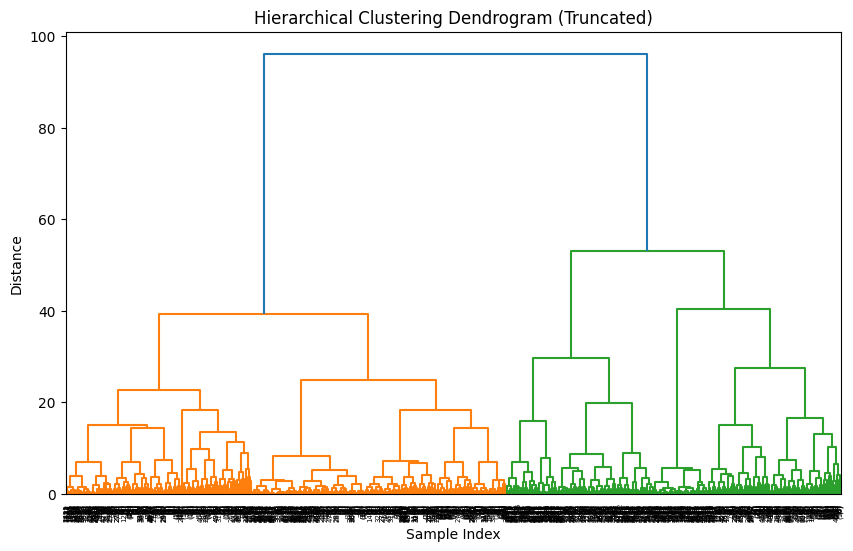


Cluster Counts:
Cluster
1    3373
3    1260
2     367
Name: count, dtype: int64


In [3]:
# Reduce dataset size to avoid memory issues
sample_size = min(5000, len(product_scaled))
sampled_data = product_scaled[:sample_size]

# Apply hierarchical clustering using Ward's method
linkage_matrix = linkage(sampled_data, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, truncate_mode="level", p=10)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Determine the optimal number of clusters and cut the dendrogram
optimal_clusters = 3
product_numeric_sampled = product_numeric.iloc[:sample_size].copy()
product_numeric_sampled['Cluster'] = fcluster(linkage_matrix, optimal_clusters, criterion='maxclust')

# Display cluster counts
print("\nCluster Counts:")
print(product_numeric_sampled['Cluster'].value_counts())


In [5]:
# Ensure the number of clusters is properly determined
optimal_clusters = 3  # Adjust based on dendrogram interpretation

# Assign clusters only to the sampled dataset to avoid index mismatch
product_numeric_sampled['Cluster'] = fcluster(linkage_matrix, optimal_clusters, criterion='maxclust')

# Merge back the cluster labels into the original dataframe
product_df.loc[product_numeric_sampled.index, 'Cluster'] = product_numeric_sampled['Cluster']

# Display cluster counts
print("\nCluster Counts:")
print(product_numeric_sampled['Cluster'].value_counts())




Cluster Counts:
Cluster
1    3373
3    1260
2     367
Name: count, dtype: int64


In [7]:
from sklearn.metrics import silhouette_score

# Ensure clustering labels are correctly assigned
sample_size = min(5000, len(product_numeric_sampled))

# Extract the sampled subset for silhouette evaluation
sampled_data = product_scaled[:sample_size]  # Standardized feature data
sampled_labels = product_numeric_sampled['Cluster'].values[:sample_size]  # Correct cluster labels

# Compute Silhouette Score
silhouette_avg = silhouette_score(sampled_data, sampled_labels)
print(f"Silhouette Score for Hierarchical Clustering (k={optimal_clusters}): {silhouette_avg:.2f}")


Silhouette Score for Hierarchical Clustering (k=3): 0.40


In [8]:
from sklearn.decomposition import PCA

# Apply PCA on the sampled data to reduce dimensions for visualization
pca = PCA(n_components=2)
product_pca = pca.fit_transform(sampled_data)  # Apply PCA only on the sampled dataset

# Assign PCA components only to the sampled subset
product_numeric_sampled['PCA1'] = product_pca[:, 0]
product_numeric_sampled['PCA2'] = product_pca[:, 1]

# Merge PCA results back into the original dataframe
product_df.loc[product_numeric_sampled.index, ['PCA1', 'PCA2']] = product_numeric_sampled[['PCA1', 'PCA2']]

# Display first few rows to verify
print(product_numeric_sampled[['Cluster', 'PCA1', 'PCA2']].head())


   Cluster      PCA1      PCA2
0        1  0.413928 -0.523356
1        1  0.321532  0.058387
2        2 -0.724326 -3.510196
3        1 -0.081939  0.175766
4        1  0.470091  0.567559


In [9]:
# Ensure merging only affects the correctly indexed subset
product_df.loc[product_numeric_sampled.index, 'Cluster'] = product_numeric_sampled['Cluster']
product_df.loc[product_numeric_sampled.index, 'PCA1'] = product_numeric_sampled['PCA1']
product_df.loc[product_numeric_sampled.index, 'PCA2'] = product_numeric_sampled['PCA2']

# Display updated DataFrame
print(product_df[['Cluster', 'PCA1', 'PCA2']].dropna().head())


   Cluster      PCA1      PCA2
0      1.0  0.413928 -0.523356
1      1.0  0.321532  0.058387
2      2.0 -0.724326 -3.510196
3      1.0 -0.081939  0.175766
4      1.0  0.470091  0.567559


<ipython-input-10-38cddd39a133>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['Cluster'] = plot_data['Cluster'].astype(int)


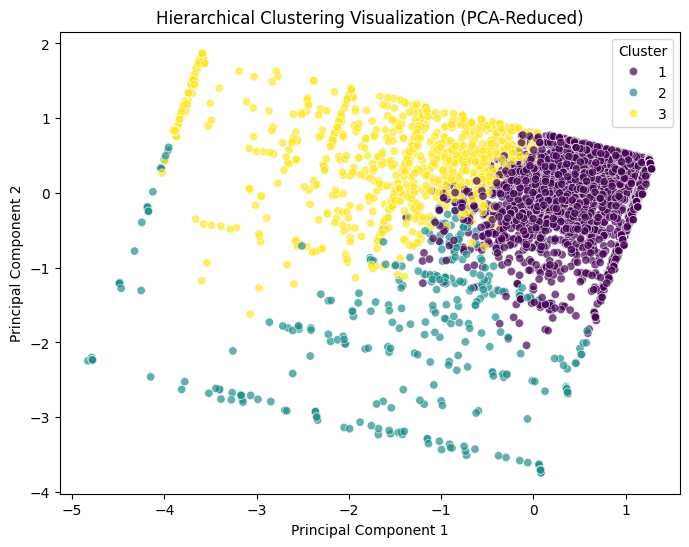

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows with missing PCA or Cluster values to avoid plotting errors
plot_data = product_df.dropna(subset=['PCA1', 'PCA2', 'Cluster'])

# Convert 'Cluster' to integer type (in case it's stored as float)
plot_data['Cluster'] = plot_data['Cluster'].astype(int)

# Plot the clusters using PCA components
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=plot_data, palette='viridis', alpha=0.7)
plt.title('Hierarchical Clustering Visualization (PCA-Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [11]:
# Ensure no NaN values in the Cluster column before counting
if product_df['Cluster'].isna().sum() > 0:
    print(f"Warning: {product_df['Cluster'].isna().sum()} rows have missing cluster assignments.")

# Drop NaN values in 'Cluster' column to avoid issues
product_df = product_df.dropna(subset=['Cluster'])

# Convert cluster labels to integers for proper counting
product_df['Cluster'] = product_df['Cluster'].astype(int)

# Display the count of each cluster
print("\nCluster Counts:")
print(product_df['Cluster'].value_counts())


Cluster Counts:
Cluster
1    3373
3    1260
2     367
Name: count, dtype: int64


<ipython-input-11-b590a928dfe9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_df['Cluster'] = product_df['Cluster'].astype(int)
